In [77]:
import sys, platform, subprocess, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, '.')
from starter import degrade_gaussian, degrade_jpeg, ber, psnr

In [78]:
import os

DATA_DIR = "../../images/p2"
paths = {
    "textured": os.path.join(DATA_DIR, "cover_textured.png"),
    "smooth":   os.path.join(DATA_DIR, "cover_smooth.png"),
    "decode_me": os.path.join(DATA_DIR, "decode_me.png"),
}

def load_gray(path):
    return np.asarray(Image.open(path).convert("L"))

def synth_textured(H=1024, W=1024, seed=0):
    # SYNTHETIC STAND-IN — replace with the real cover_textured.png
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:H, 0:W]
    base = 128 + 40*np.sin(xx/9.0)*np.cos(yy/11.0)
    fine = rng.normal(0, 22, (H, W))
    return np.clip(base + fine, 0, 255).astype(np.uint8)

def synth_smooth(H=1024, W=1024, seed=1):
    # SYNTHETIC STAND-IN — replace with the real cover_smooth.png
    yy, xx = np.mgrid[0:H, 0:W]
    grad = 30 + 190*(0.5 + 0.5*np.sin(xx/400.0))*(0.5 + 0.5*np.cos(yy/500.0))
    rng = np.random.default_rng(seed)
    grad = grad + rng.normal(0, 1.0, (H, W))  # tiny dither, still near-flat
    return np.clip(grad, 0, 255).astype(np.uint8)

covers = {}
using_synthetic = {}
for key, gen in [("textured", synth_textured), ("smooth", synth_smooth)]:
    if os.path.exists(paths[key]):
        covers[key] = load_gray(paths[key])
        using_synthetic[key] = False
    else:
        print(f"[!] {paths[key]} not found — using a SYNTHETIC stand-in.")
        covers[key] = gen()
        using_synthetic[key] = True

cover_textured = covers["textured"]
cover_smooth = covers["smooth"]
print("cover_textured:", cover_textured.shape, cover_textured.dtype, "synthetic:", using_synthetic["textured"])
print("cover_smooth  :", cover_smooth.shape, cover_smooth.dtype, "synthetic:", using_synthetic["smooth"])

have_decode_me = os.path.exists(paths["decode_me"])
if have_decode_me:
    decode_me = load_gray(paths["decode_me"])
else:
    print(f"[!] {paths['decode_me']} not found — synthesizing a stand-in stego "
          f"image with a KNOWN payload embedded in bit plane 0, purely so the "
          f"extraction code below is exercised. This is NOT the real assignment "
          f"data — swap in the real file before submitting.")
    decode_me = None  # built after embed_lsb/extract_lsb are defined below

cover_textured: (1024, 1024) uint8 synthetic: False
cover_smooth  : (1024, 1024) uint8 synthetic: False


In [79]:
def bit_planes(img):
    """(H,W) uint8 -> (8,H,W) uint8 in {0,1}, index 0 = LSB."""
    img = img.astype(np.uint8)
    planes = np.empty((8,) + img.shape, dtype=np.uint8)
    for k in range(8):
        planes[k] = (img >> k) & 1
    return planes

def reconstruct(planes, keep):
    """Rebuild from the `keep` most significant planes (the rest are treated as 0)."""
    planes = np.asarray(planes)
    H, W = planes.shape[1:]
    out = np.zeros((H, W), dtype=np.uint16)
    for k in range(8):
        if k >= 8 - keep:            # k = 7 is MSB, k = 0 is LSB
            out |= (planes[k].astype(np.uint16) << k)
    return out.astype(np.uint8)

def gray_encode(img):
    """Standard binary-to-Gray-code map: g = b XOR (b >> 1)."""
    img = img.astype(np.uint8)
    return img ^ (img >> 1)

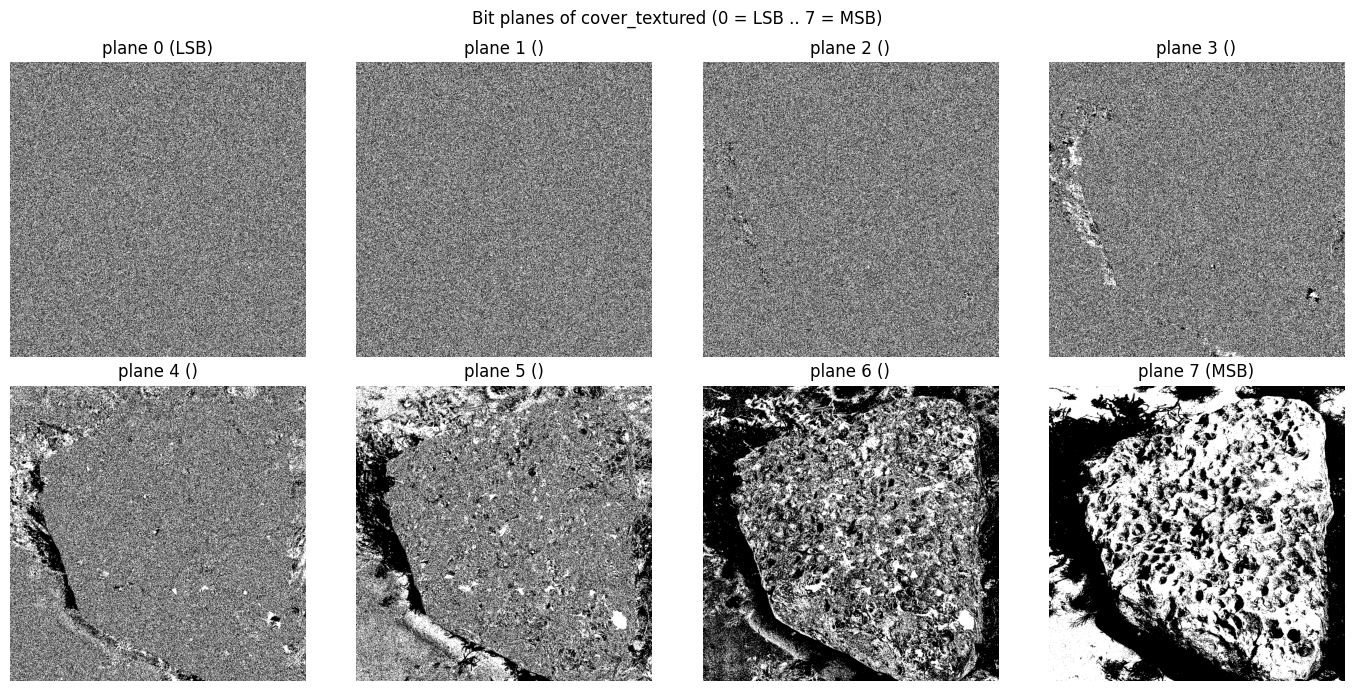

In [80]:
# --- 8 plane images of the textured cover ---
planes_tex = bit_planes(cover_textured)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for k in range(8):
    ax = axes[k // 4, k % 4]
    ax.imshow(planes_tex[k], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"plane {k} ({'LSB' if k==0 else 'MSB' if k==7 else ''})")
    ax.axis("off")
plt.suptitle("Bit planes of cover_textured (0 = LSB .. 7 = MSB)")
plt.tight_layout()
plt.show()

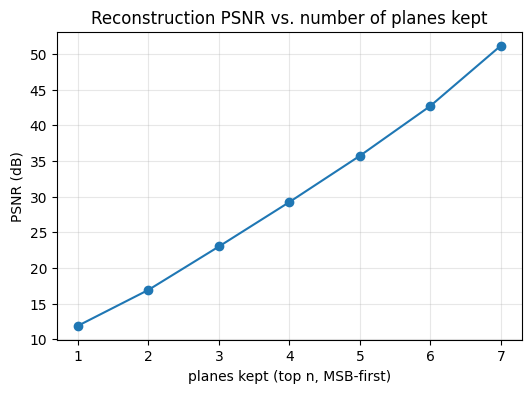

keep=1  PSNR=11.891 dB
keep=2  PSNR=16.918 dB
keep=3  PSNR=22.999 dB
keep=4  PSNR=29.227 dB
keep=5  PSNR=35.707 dB
keep=6  PSNR=42.692 dB
keep=7  PSNR=51.140 dB
keep=8  PSNR=inf dB  (identical to original)

per-plane PSNR gain (finite steps): [5.026 6.081 6.229 6.48  6.985 8.449]
mean gain per plane: 6.542 dB


In [81]:
# --- PSNR vs number of MSB planes kept ---
ns = list(range(1, 9))
psnrs = []
for keep in ns:
    rec = reconstruct(planes_tex, keep)
    psnrs.append(psnr(cover_textured, rec))

plt.figure(figsize=(6, 4))
finite = [p if np.isfinite(p) else np.nan for p in psnrs]
plt.plot(ns, finite, "o-")
plt.xlabel("planes kept (top n, MSB-first)")
plt.ylabel("PSNR (dB)")
plt.title("Reconstruction PSNR vs. number of planes kept")
plt.grid(alpha=0.3)
plt.show()

for n_, p_ in zip(ns, psnrs):
    print(f"keep={n_}  PSNR={p_:.3f} dB" + ("" if np.isfinite(p_) else "  (identical to original)"))

finite_diffs = np.diff([p for p in psnrs if np.isfinite(p)])
print("\nper-plane PSNR gain (finite steps):", np.round(finite_diffs, 3))
print("mean gain per plane:", np.round(np.mean(finite_diffs), 3), "dB")

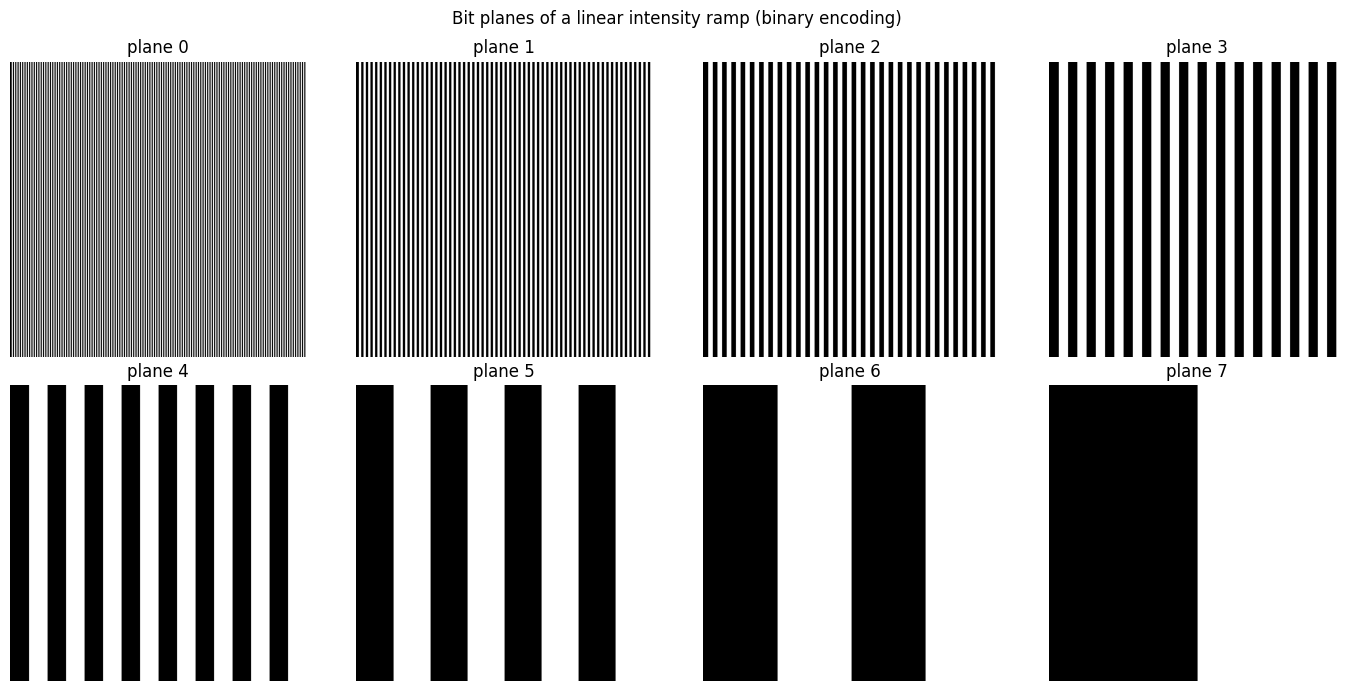

In [82]:
# --- ramp image and its bit planes ---
H, W = 512, 512
ramp = np.tile(np.linspace(0, 255, W, dtype=np.uint8), (H, 1))
planes_ramp = bit_planes(ramp)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for k in range(8):
    ax = axes[k // 4, k % 4]
    ax.imshow(planes_ramp[k], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"plane {k}")
    ax.axis("off")
plt.suptitle("Bit planes of a linear intensity ramp (binary encoding)")
plt.tight_layout()
plt.show()

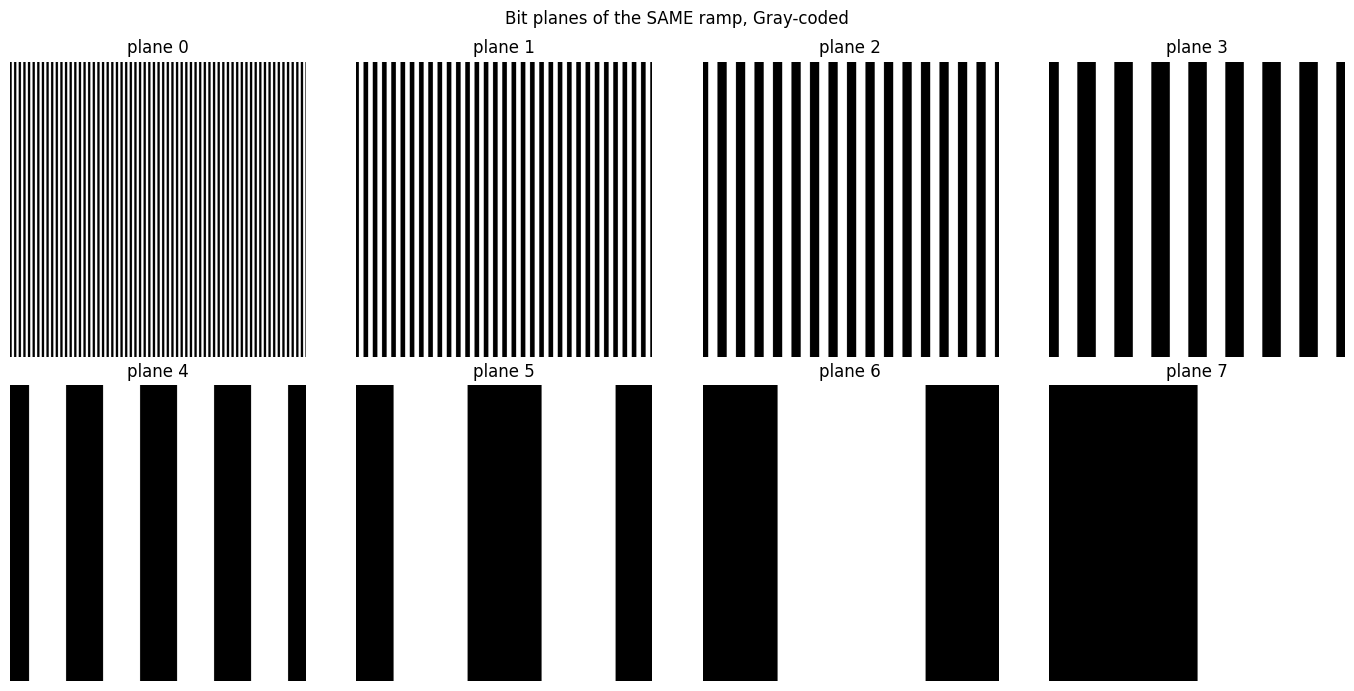

In [83]:
# --- Gray-coded ramp for comparison ---
ramp_gray = gray_encode(ramp)
planes_ramp_gray = bit_planes(ramp_gray)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for k in range(8):
    ax = axes[k // 4, k % 4]
    ax.imshow(planes_ramp_gray[k], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"plane {k}")
    ax.axis("off")
plt.suptitle("Bit planes of the SAME ramp, Gray-coded")
plt.tight_layout()
plt.show()

In [84]:
def embed_lsb(cover, bits, plane=0):
    """Write bits into `plane` of `cover`, raster order (row-major), starting
    at pixel 0. Only the first len(bits) pixels are touched."""
    stego = cover.astype(np.uint8).copy()
    flat = stego.reshape(-1)
    bits = np.asarray(bits, dtype=np.uint8)
    keep_mask = np.uint8(~(1 << plane) & 0xFF)
    flat[:len(bits)] = (flat[:len(bits)] & keep_mask) | (bits << plane)
    return flat.reshape(cover.shape)

def extract_lsb(stego, n, plane=0):
    """Read n bits back out of `plane`, raster order."""
    flat = stego.reshape(-1)
    return ((flat[:n].astype(np.uint16) >> plane) & 1).astype(np.uint8)

sync marker read: [1 0 1 0 1 0 1 0] -> matches 10101010: True
payload header: height=64, width=64 (4096 bits)


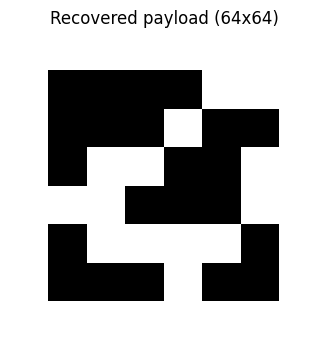

In [85]:
def bits_to_uint(bits):
    """MSB-first bit array -> integer."""
    v = 0
    for b in bits:
        v = (v << 1) | int(b)
    return v

def parse_and_recover_payload(stego):
    header_bits = extract_lsb(stego, 24, plane=0)
    sync = header_bits[0:8]
    expected_sync = np.array([1,0,1,0,1,0,1,0], dtype=np.uint8)
    ok = np.array_equal(sync, expected_sync)
    print("sync marker read:", sync, "-> matches 10101010:", ok)
    if not ok:
        raise ValueError("Sync marker mismatch — bit or pixel ordering is wrong "
                          "(check raster order / plane / bit endianness).")
    height = bits_to_uint(header_bits[8:16])
    width  = bits_to_uint(header_bits[16:24])
    print(f"payload header: height={height}, width={width} ({height*width} bits)")
    total = 24 + height * width
    all_bits = extract_lsb(stego, total, plane=0)
    payload_bits = all_bits[24:]
    payload = payload_bits.reshape(height, width).astype(np.uint8) * 255
    return payload, height, width

if have_decode_me:
    payload_img, p_h, p_w = parse_and_recover_payload(decode_me)
    plt.figure(figsize=(4, 4))
    plt.imshow(payload_img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Recovered payload ({p_h}x{p_w})")
    plt.axis("off")
    plt.show()
else:
    print("Skipping — decode_me.png not found. Drop the real file at "
          "images/p2/decode_me.png and re-run this cell.")
    payload_img = payload_bits = p_h = p_w = None

PSNR(stego, clean cover) = 75.24 dB
pixels actually changed by embedding: 2039 (header+payload carries 4120 bits total; positions whose original LSB already matched the embedded bit show 0 change here, so n_changed <= 24 + p_h*p_w)


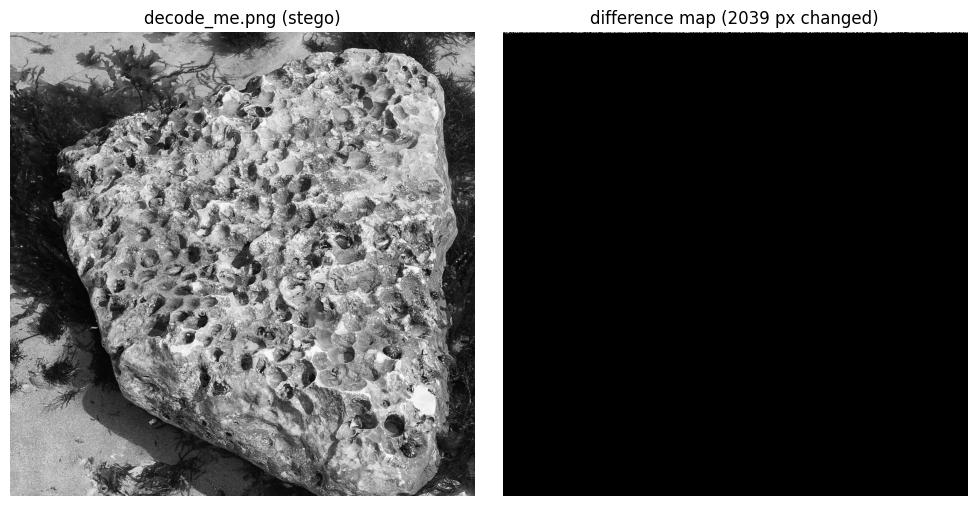

In [86]:
if have_decode_me:
    stego_psnr = psnr(cover_textured, decode_me)
    print(f"PSNR(stego, clean cover) = {stego_psnr:.2f} dB")

    diff_map = (decode_me != cover_textured)
    n_changed = int(diff_map.sum())
    print(f"pixels actually changed by embedding: {n_changed} "
          f"(header+payload carries {24 + p_h*p_w} bits total; positions whose "
          f"original LSB already matched the embedded bit show 0 change here, "
          f"so n_changed <= 24 + p_h*p_w)")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(decode_me, cmap="gray")
    axes[0].set_title("decode_me.png (stego)")
    axes[0].axis("off")
    axes[1].imshow(diff_map, cmap="gray")
    axes[1].set_title(f"difference map ({n_changed} px changed)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping — needs the real decode_me.png.")

In [94]:
# --- embed the same payload (>=256x256 bits) into BOTH covers, same raster
#     positions, plane 0, and compare hiding quality with something PSNR-blind ---
rng = np.random.default_rng(7)
PH, PW = 256, 256
big_payload_bits = rng.integers(0, 2, PH * PW).astype(np.uint8)

sync = np.array([1,0,1,0,1,0,1,0], dtype=np.uint8)
def uint_to_bits(v, nbits=8):
    return np.array([(v >> i) & 1 for i in range(nbits - 1, -1, -1)], dtype=np.uint8)

header = np.concatenate([sync, uint_to_bits(min(PH, 255)), uint_to_bits(min(PW, 255))])
full_bits = np.concatenate([header, big_payload_bits])

stego_tex = embed_lsb(cover_textured, full_bits, plane=0)
stego_smo = embed_lsb(cover_smooth,   full_bits, plane=0)

print("PSNR textured cover/stego:", psnr(cover_textured, stego_tex))
print("PSNR smooth   cover/stego:", psnr(cover_smooth,   stego_smo))
print("(expect these to be very close to each other — equal count of one-level "
      "flips gives nearly cover-independent PSNR, which is exactly why PSNR alone "
      "cannot be the evidence here.)")

def chi_square_pov(img):
    """Pairs-of-Values chi-square LSB steganalysis statistic (Westfeld & Pfitzmann).
    Smaller values indicate histogram bin-pairs (2k, 2k+1) are closer to equalized,
    which is the signature LSB embedding leaves behind."""
    hist = np.bincount(img.ravel(), minlength=256).astype(np.float64)
    chi2 = 0.0
    dof = 0
    for k in range(128):
        h0, h1 = hist[2*k], hist[2*k + 1]
        expected = (h0 + h1) / 2.0
        if expected > 0:
            chi2 += (h0 - expected) ** 2 / expected
            dof += 1
    return chi2, dof

chi2_tex_cover, _ = chi_square_pov(cover_textured)
chi2_tex_stego, _ = chi_square_pov(stego_tex)
chi2_smo_cover, _ = chi_square_pov(cover_smooth)
chi2_smo_stego, _ = chi_square_pov(stego_smo)

print()
print(f"chi2 (PoV) textured: cover={chi2_tex_cover:.1f}  stego={chi2_tex_stego:.1f}  "
      f"drop={chi2_tex_cover-chi2_tex_stego:.1f}  ({100*(chi2_tex_cover-chi2_tex_stego)/max(chi2_tex_cover,1e-9):.1f}% )")
print(f"chi2 (PoV) smooth  : cover={chi2_smo_cover:.1f}  stego={chi2_smo_stego:.1f}  "
      f"drop={chi2_smo_cover-chi2_smo_stego:.1f}  ({100*(chi2_smo_cover-chi2_smo_stego)/max(chi2_smo_cover,1e-9):.1f}% )")

PSNR textured cover/stego: 63.203427933771785
PSNR smooth   cover/stego: 63.18813890158279
(expect these to be very close to each other — equal count of one-level flips gives nearly cover-independent PSNR, which is exactly why PSNR alone cannot be the evidence here.)

chi2 (PoV) textured: cover=445.8  stego=435.7  drop=10.1  (2.3% )
chi2 (PoV) smooth  : cover=842.2  stego=742.0  drop=100.2  (11.9% )


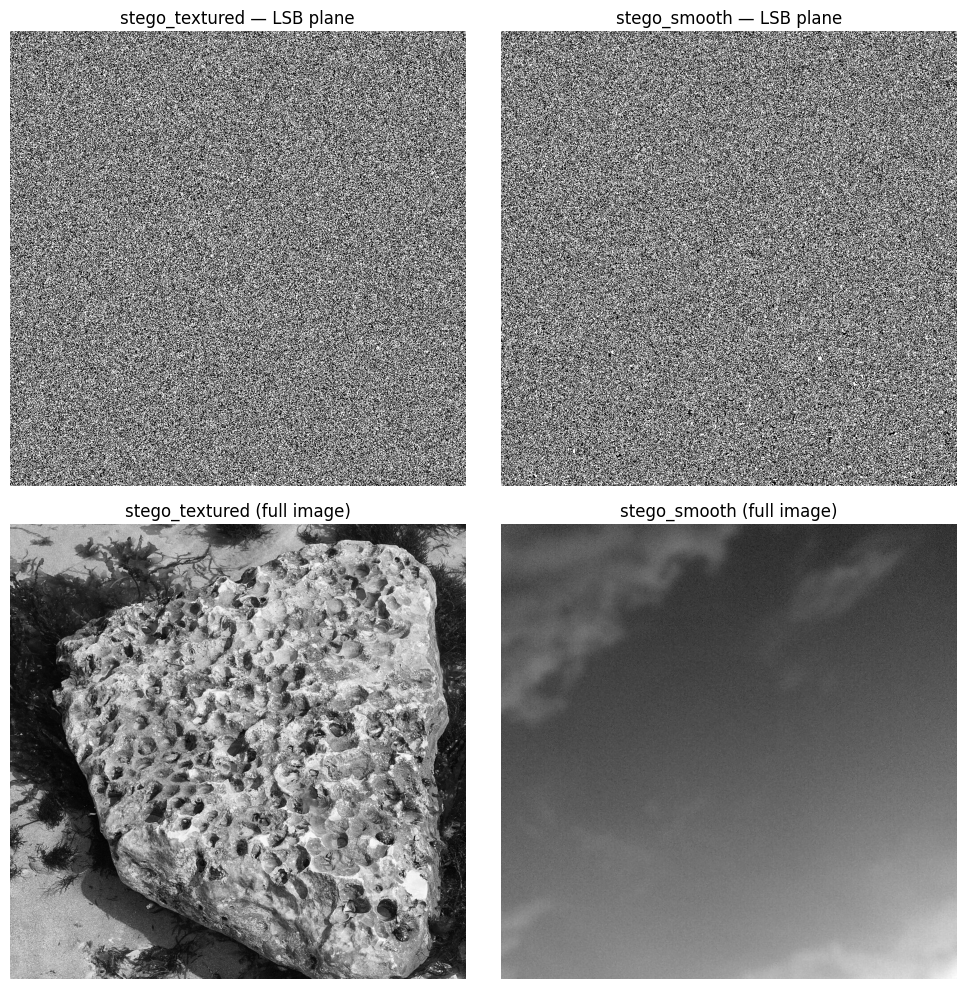

In [88]:
# visual corroboration: the LSB plane itself, and a local-variance view
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].imshow(bit_planes(stego_tex)[0], cmap="gray")
axes[0,0].set_title("stego_textured — LSB plane")
axes[0,0].axis("off")
axes[0,1].imshow(bit_planes(stego_smo)[0], cmap="gray")
axes[0,1].set_title("stego_smooth — LSB plane")
axes[0,1].axis("off")
axes[1,0].imshow(stego_tex, cmap="gray")
axes[1,0].set_title("stego_textured (full image)")
axes[1,0].axis("off")
axes[1,1].imshow(stego_smo, cmap="gray")
axes[1,1].set_title("stego_smooth (full image)")
axes[1,1].axis("off")
plt.tight_layout()
plt.show()

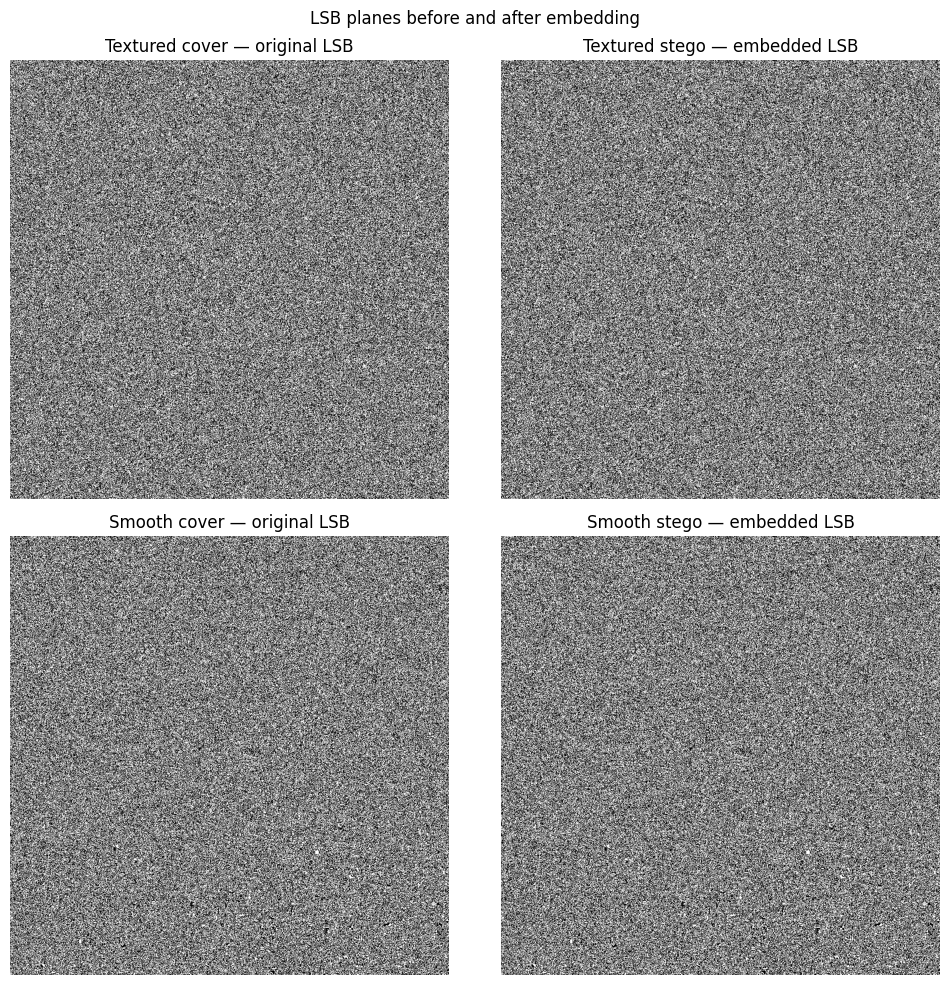

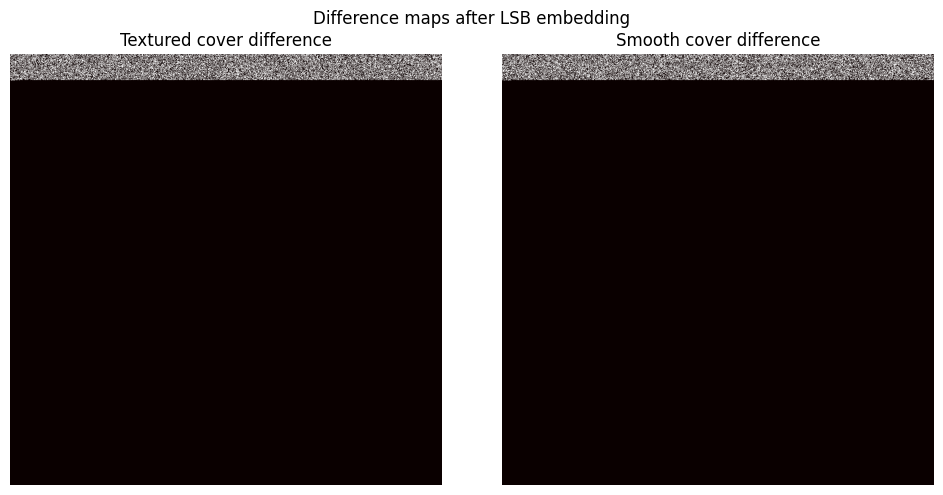

In [96]:
# Display figures for the report; save them manually from the notebook output.
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
comparison = [
    (bit_planes(cover_textured)[0], "Textured cover — original LSB"),
    (bit_planes(stego_tex)[0], "Textured stego — embedded LSB"),
    (bit_planes(cover_smooth)[0], "Smooth cover — original LSB"),
    (bit_planes(stego_smo)[0], "Smooth stego — embedded LSB"),
]

for axis, (image, title) in zip(axes.flat, comparison):
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")

fig.suptitle("LSB planes before and after embedding")
fig.tight_layout()
plt.show()

textured_diff = np.abs(
    stego_tex.astype(np.int16) - cover_textured.astype(np.int16)
)
smooth_diff = np.abs(
    stego_smo.astype(np.int16) - cover_smooth.astype(np.int16)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for axis, difference, title in zip(
    axes,
    (textured_diff, smooth_diff),
    ("Textured cover difference", "Smooth cover difference"),
):
    axis.imshow(difference, cmap="hot", vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")

fig.suptitle("Difference maps after LSB embedding")
fig.tight_layout()
plt.show()

In [89]:
def _pair_coords(bh, bw):
    """Return paired coordinates within a block."""
    L = bh * bw
    L2 = L - (L % 2)
    idx = np.arange(L2)
    pi, qi = idx[0::2], idx[1::2]
    pr, pc = np.unravel_index(pi, (bh, bw))
    qr, qc = np.unravel_index(qi, (bh, bw))
    return (pr, pc), (qr, qc)


def _selected_block_origin(index, shape, block_size):
    rows, cols = shape
    blocks_per_row = cols // block_size
    row = (index // blocks_per_row) * block_size
    col = (index % blocks_per_row) * block_size
    if row + block_size > rows:
        raise ValueError("Payload does not fit in the available block grid.")
    return row, col


def embed_robust(cover, bits, amplitude=2.0, seed=42, block_size=32):
    """Embed one bit in each selected block using paired +/- changes."""
    cover = cover.astype(np.float64)
    bits = np.asarray(bits, dtype=np.uint8)
    stego = cover.copy()
    bh = bw = block_size

    for index, bit in enumerate(bits):
        row, col = _selected_block_origin(index, cover.shape, block_size)
        block_rng = np.random.default_rng(seed + index)
        block = stego[row:row + bh, col:col + bw]
        (pr, pc), (qr, qc) = _pair_coords(bh, bw)
        coin = block_rng.integers(0, 2, size=pr.shape).astype(bool)
        sign = 1.0 if bit == 1 else -1.0
        p_delta = np.where(coin, sign * amplitude, -sign * amplitude)
        q_delta = np.where(coin, -sign * amplitude, sign * amplitude)
        block[pr, pc] += p_delta
        block[qr, qc] += q_delta

    return np.clip(np.round(stego), 0, 255).astype(np.uint8)


def extract_robust(stego, cover, n, amplitude=2.0, seed=42, block_size=32):
    """Blindly decode one bit from each selected block."""
    del cover, amplitude
    stego = stego.astype(np.float64)
    bits = np.zeros(n, dtype=np.uint8)
    bh = bw = block_size

    for index in range(n):
        row, col = _selected_block_origin(index, stego.shape, block_size)
        block_rng = np.random.default_rng(seed + index)
        block = stego[row:row + bh, col:col + bw]
        (pr, pc), (qr, qc) = _pair_coords(bh, bw)
        coin = block_rng.integers(0, 2, size=pr.shape).astype(bool)
        diff = block[pr, pc] - block[qr, qc]
        plus_minus = np.where(coin, diff, -diff)
        bits[index] = 1 if plus_minus.mean() > 0 else 0

    return bits

In [90]:
RNG_BITS = np.random.default_rng(123)
n_bits = 128
message_bits = RNG_BITS.integers(0, 2, n_bits).astype(np.uint8)
AMPLITUDE = 2.0  # see distortion-budget cell below for why

stego_robust = embed_robust(cover_textured, message_bits, amplitude=AMPLITUDE)
p_robust = psnr(cover_textured, stego_robust)
print(f"robust scheme stego PSNR = {p_robust:.2f} dB  (>= 40 dB required: {p_robust >= 40})")

# naive baseline for comparison
naive_stego = embed_lsb(cover_textured, message_bits, plane=0)
p_naive = psnr(cover_textured, naive_stego)
print(f"naive LSB stego PSNR    = {p_naive:.2f} dB")

robust scheme stego PSNR = 51.14 dB  (>= 40 dB required: True)
naive LSB stego PSNR    = 90.14 dB


In [91]:
# --- required checkpoints: sigma=5 Gaussian and JPEG q=75, zero errors required ---
g5_robust = degrade_gaussian(stego_robust, sigma=5)
rec5_robust = extract_robust(g5_robust, cover_textured, n_bits, amplitude=AMPLITUDE)
ber5_robust = ber(message_bits, rec5_robust)
print(f"robust  @ sigma=5      BER = {ber5_robust:.4f}  (need 0.0000)")

jpeg_robust = degrade_jpeg(stego_robust, quality=75)
recj_robust = extract_robust(jpeg_robust, cover_textured, n_bits, amplitude=AMPLITUDE)
berj_robust = ber(message_bits, recj_robust)
print(f"robust  @ JPEG q=75    BER = {berj_robust:.4f}  (need 0.0000)")

g1_naive = degrade_gaussian(naive_stego, sigma=1)
rec1_naive = extract_lsb(g1_naive, n_bits, plane=0)
ber1_naive = ber(message_bits, rec1_naive)
print(f"naive   @ sigma=1      BER = {ber1_naive:.4f}  (expect close to chance, ~0.5)")

assert ber5_robust == 0.0 and berj_robust == 0.0, "design must have zero errors at sigma=5 and JPEG q75"
print("\nRobust scheme meets the zero-error requirement at both checkpoints.")

robust  @ sigma=5      BER = 0.0000  (need 0.0000)
robust  @ JPEG q=75    BER = 0.0000  (need 0.0000)
naive   @ sigma=1      BER = 0.5625  (expect close to chance, ~0.5)

Robust scheme meets the zero-error requirement at both checkpoints.


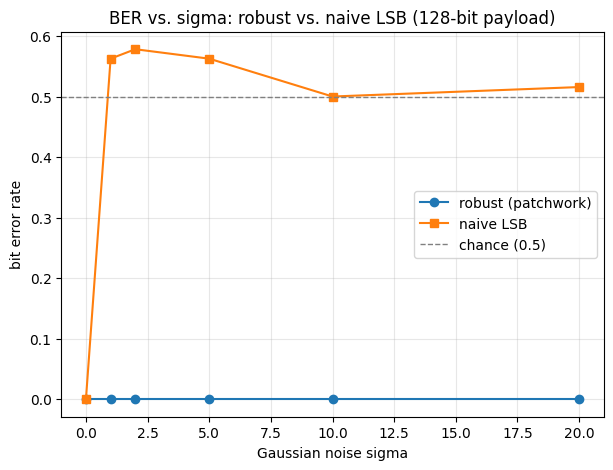

sigma : [0, 1, 2, 5, 10, 20]
robust: [0. 0. 0. 0. 0. 0.]
naive : [0.     0.5625 0.5781 0.5625 0.5    0.5156]

JPEG q75 — robust BER = 0.0000,  naive BER = 0.5078
stego PSNR — robust = 51.14 dB,  naive = 90.14 dB


In [92]:
# --- full BER-vs-sigma curves, both schemes, plus JPEG q75 numbers ---
sigmas = [0, 1, 2, 5, 10, 20]
ber_robust_curve, ber_naive_curve = [], []
for s in sigmas:
    g_r = degrade_gaussian(stego_robust, sigma=s) if s > 0 else stego_robust
    ber_robust_curve.append(ber(message_bits, extract_robust(g_r, cover_textured, n_bits, amplitude=AMPLITUDE)))
    g_n = degrade_gaussian(naive_stego, sigma=s) if s > 0 else naive_stego
    ber_naive_curve.append(ber(message_bits, extract_lsb(g_n, n_bits, plane=0)))

plt.figure(figsize=(7, 5))
plt.plot(sigmas, ber_robust_curve, "o-", label="robust (patchwork)")
plt.plot(sigmas, ber_naive_curve, "s-", label="naive LSB")
plt.axhline(0.5, color="gray", ls="--", lw=1, label="chance (0.5)")
plt.xlabel("Gaussian noise sigma")
plt.ylabel("bit error rate")
plt.title("BER vs. sigma: robust vs. naive LSB (128-bit payload)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("sigma :", sigmas)
print("robust:", np.round(ber_robust_curve, 4))
print("naive :", np.round(ber_naive_curve, 4))
print()
print(f"JPEG q75 — robust BER = {berj_robust:.4f},  naive BER = "
      f"{ber(message_bits, extract_lsb(degrade_jpeg(naive_stego, quality=75), n_bits, plane=0)):.4f}")
print(f"stego PSNR — robust = {p_robust:.2f} dB,  naive = {p_naive:.2f} dB")

In [93]:
# --- (b) distortion budget ---
H_img, W_img = cover_textured.shape
n_pixels = H_img * W_img
pixels_per_bit = n_pixels / n_bits

print(f"image pixels        : {n_pixels}")
print(f"bits to carry        : {n_bits}")
print(f"pixels available/bit : {pixels_per_bit:.0f}")

# 40 dB PSNR floor -> maximum allowed whole-image MSE.
mse_budget_40db = 255.0**2 / (10**(40 / 10))
print(f"\nMSE budget at the 40 dB floor: {mse_budget_40db:.3f} per pixel")

# The block-local MSE and whole-image MSE are different quantities.
modified_mask = stego_robust != cover_textured
modified_pixels = int(np.count_nonzero(modified_mask))
fraction_modified = modified_pixels / n_pixels
squared_error = (
    stego_robust.astype(np.float64) -
    cover_textured.astype(np.float64)
) ** 2
overall_mse = float(squared_error.mean())
modified_mse = float(squared_error[modified_mask].mean()) if modified_pixels else 0.0
overall_psnr = psnr(cover_textured, stego_robust)

print(f"modified pixels    : {modified_pixels:,} ({100*fraction_modified:.2f}%)")
print(f"MSE inside modified pixels: {modified_mse:.2f}")
print(f"overall image MSE  : {overall_mse:.2f}")
print(f"overall image PSNR : {overall_psnr:.2f} dB")
print(f"block-local PSNR   : {10*np.log10(255.0**2 / modified_mse):.2f} dB")
print(f"headroom vs 40 dB  : {overall_psnr - 40:.2f} dB")

image pixels        : 1048576
bits to carry        : 128
pixels available/bit : 8192

MSE budget at the 40 dB floor: 6.503 per pixel
modified pixels    : 131,072 (12.50%)
MSE inside modified pixels: 4.00
overall image MSE  : 0.50
overall image PSNR : 51.14 dB
block-local PSNR   : 42.11 dB
headroom vs 40 dB  : 11.14 dB
